AQI records: (1827, 15)
Matched satellite records: (544, 4)

TOP 10 MOST POLLUTED SATELLITE DATES
          Date    AQI  Pollution_Coverage
504 2024-11-19  215.4          100.000000
500 2024-11-11  399.7          100.000000
503 2024-11-17  172.2          100.000000
399 2024-12-27   53.7          100.000000
396 2024-12-21  405.2          100.000000
395 2024-12-19  125.1          100.000000
393 2024-12-15  160.4          100.000000
497 2024-11-05  120.9           99.998474
502 2024-11-15  480.2           99.990845
498 2024-11-07  145.8           99.984741


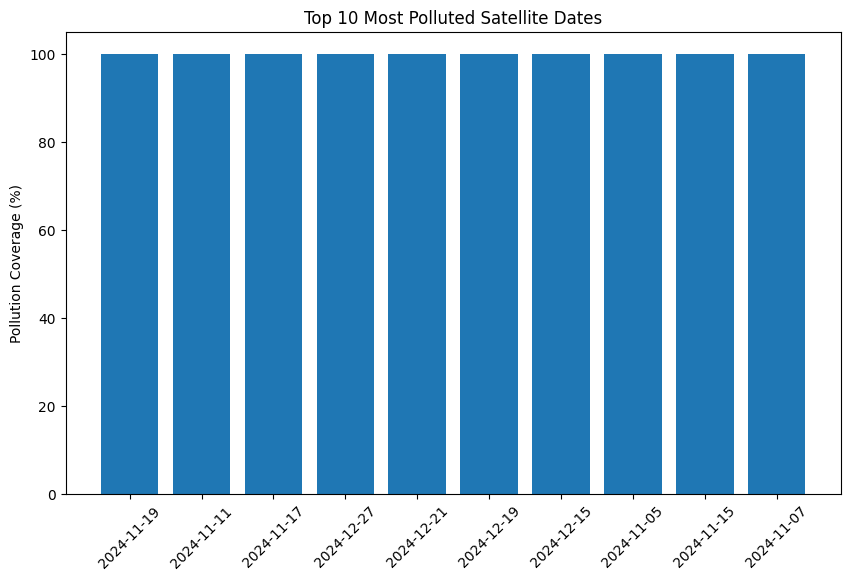


MONTHLY SATELLITE ANALYSIS
              AQI  Pollution_Coverage
Month                                
1      264.606667           76.368679
2      226.057143           57.572683
3      225.163043           51.134657
4      227.582222           63.901672
5      254.522222           71.100498
6      238.212766           80.100559
7      275.548936           88.763947
8      261.633333           83.192512
9      267.619149           67.670132
10     199.702174           48.826798
11     217.686364           75.590723
12     218.426667           62.289090


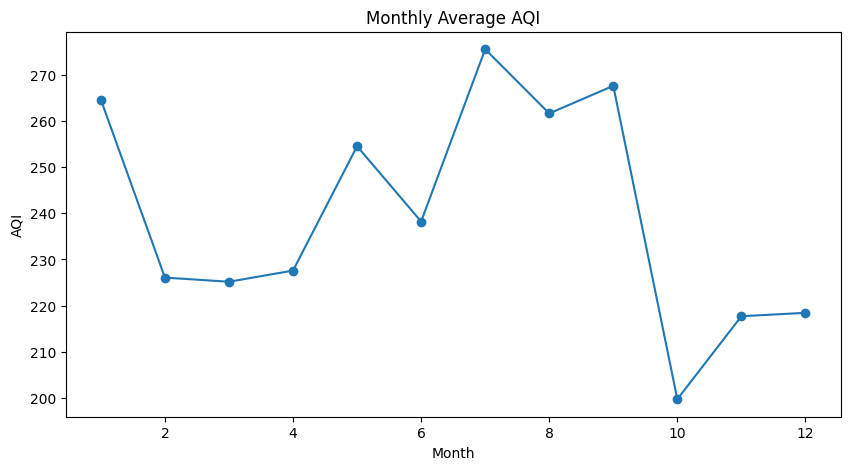

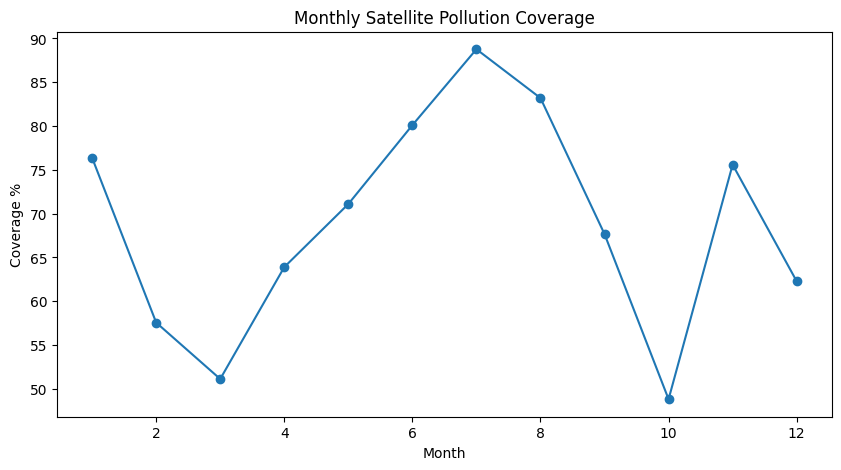


Cleanest Month: 10
Most Polluted Month: 7


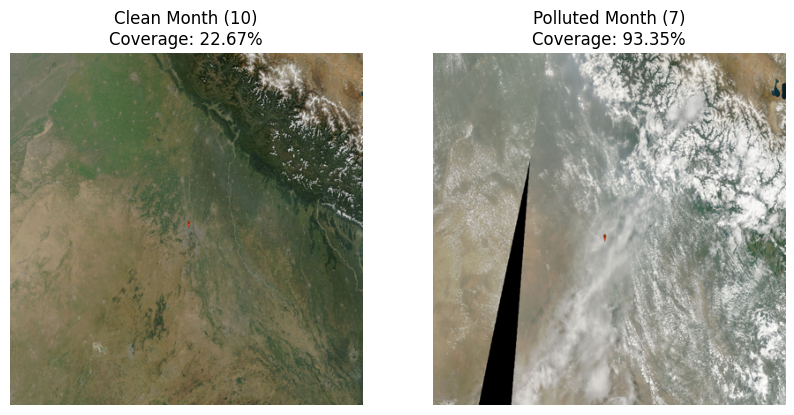

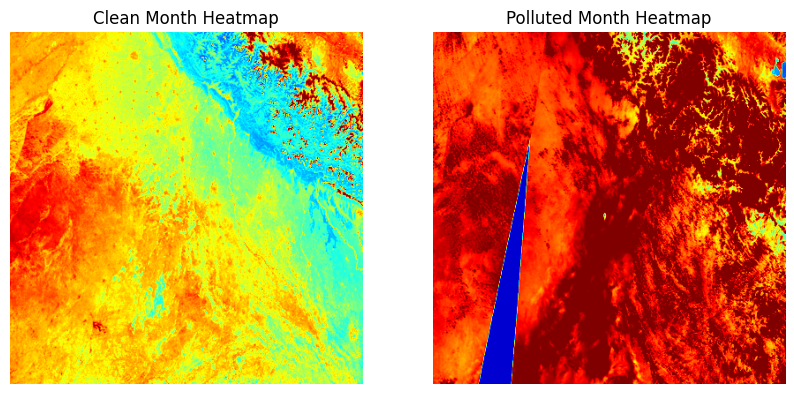

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# =========================
# LOAD AQI DATA
# =========================
df = pd.read_csv("../data/cleaned_aqi_final.csv")
df['Date'] = pd.to_datetime(df['Date'])

print("AQI records:", df.shape)

# =========================
# SATELLITE FOLDER
# =========================
base_folder = "../satellite images"

results = []

# =========================
# PROCESS ALL IMAGES
# =========================
for root, dirs, files in os.walk(base_folder):
    for file in files:

        if file.lower().endswith((".png", ".jpg", ".jpeg")):

            try:
                date_str = file.split(".")[0]
                img_date = pd.to_datetime(date_str)

                img_path = os.path.join(root, file)

                img = Image.open(img_path).convert("RGB")
                img = img.resize((256, 256))

                img_np = np.array(img)

                # enhancement
                enhanced = cv2.convertScaleAbs(
                    img_np,
                    alpha=1.4,
                    beta=20
                )

                # grayscale
                gray = cv2.cvtColor(
                    enhanced,
                    cv2.COLOR_RGB2GRAY
                )

                # hotspot threshold
                _, mask = cv2.threshold(
                    gray,
                    180,
                    255,
                    cv2.THRESH_BINARY
                )

                polluted_pixels = np.sum(mask == 255)
                total_pixels = mask.size

                pollution_percent = (
                    polluted_pixels / total_pixels
                ) * 100

                match = df[df['Date'] == img_date]

                if len(match) > 0:
                    aqi = match['AQI'].values[0]

                    results.append([
                        img_date,
                        aqi,
                        pollution_percent,
                        img_path
                    ])

            except:
                pass

# =========================
# RESULTS
# =========================
sat_df = pd.DataFrame(
    results,
    columns=[
        'Date',
        'AQI',
        'Pollution_Coverage',
        'Image_Path'
    ]
)

print("Matched satellite records:", sat_df.shape)

# =========================
# TOP POLLUTED DATES
# =========================
top_polluted = sat_df.sort_values(
    'Pollution_Coverage',
    ascending=False
).head(10)

print("\nTOP 10 MOST POLLUTED SATELLITE DATES")
print(top_polluted[['Date', 'AQI', 'Pollution_Coverage']])

# =========================
# BAR CHART
# =========================
plt.figure(figsize=(10,6))

plt.bar(
    top_polluted['Date'].astype(str),
    top_polluted['Pollution_Coverage']
)

plt.xticks(rotation=45)
plt.ylabel("Pollution Coverage (%)")
plt.title("Top 10 Most Polluted Satellite Dates")

plt.show()

# =========================
# MONTHLY COMPARISON
# =========================
sat_df['Month'] = sat_df['Date'].dt.month

monthly = sat_df.groupby('Month')[
    ['AQI', 'Pollution_Coverage']
].mean()

print("\nMONTHLY SATELLITE ANALYSIS")
print(monthly)

# AQI
plt.figure(figsize=(10,5))
plt.plot(
    monthly.index,
    monthly['AQI'],
    marker='o'
)

plt.title("Monthly Average AQI")
plt.xlabel("Month")
plt.ylabel("AQI")
plt.show()

# Satellite
plt.figure(figsize=(10,5))
plt.plot(
    monthly.index,
    monthly['Pollution_Coverage'],
    marker='o'
)

plt.title("Monthly Satellite Pollution Coverage")
plt.xlabel("Month")
plt.ylabel("Coverage %")
plt.show()

# =========================
# CLEANEST VS MOST POLLUTED MONTH
# =========================
clean_month = monthly['Pollution_Coverage'].idxmin()
polluted_month = monthly['Pollution_Coverage'].idxmax()

print("\nCleanest Month:", clean_month)
print("Most Polluted Month:", polluted_month)

# =========================
# SAMPLE IMAGE COMPARISON
# =========================
clean_sample = sat_df[
    sat_df['Date'].dt.month == clean_month
].iloc[0]

polluted_sample = sat_df[
    sat_df['Date'].dt.month == polluted_month
].iloc[0]

clean_img = Image.open(clean_sample['Image_Path']).resize((400,400))
polluted_img = Image.open(polluted_sample['Image_Path']).resize((400,400))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(clean_img)
plt.title(
    f"Clean Month ({clean_month})\nCoverage: {clean_sample['Pollution_Coverage']:.2f}%"
)
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(polluted_img)
plt.title(
    f"Polluted Month ({polluted_month})\nCoverage: {polluted_sample['Pollution_Coverage']:.2f}%"
)
plt.axis("off")

plt.show()

# =========================
# HOTSPOT VISUAL COMPARISON
# =========================
def generate_hotspot(path):
    img = Image.open(path).convert("RGB")
    img = img.resize((400,400))

    img_np = np.array(img)

    enhanced = cv2.convertScaleAbs(
        img_np,
        alpha=1.4,
        beta=20
    )

    gray = cv2.cvtColor(
        enhanced,
        cv2.COLOR_RGB2GRAY
    )

    _, mask = cv2.threshold(
        gray,
        180,
        255,
        cv2.THRESH_BINARY
    )

    heatmap = cv2.applyColorMap(
        gray,
        cv2.COLORMAP_JET
    )

    return cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

clean_hotspot = generate_hotspot(clean_sample['Image_Path'])
polluted_hotspot = generate_hotspot(polluted_sample['Image_Path'])

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(clean_hotspot)
plt.title("Clean Month Heatmap")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(polluted_hotspot)
plt.title("Polluted Month Heatmap")
plt.axis("off")

plt.show()